In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score
from src.visualization import evaluate_and_plot_models
# Import modularized functions
from src.metrics import compute_psi, calculate_psi_dataframe, compute_holdout_metrics, generate_shap_waterfalls
from src.feature_engineering import (
    process_bureau_data,
    DropHighMissingColumns,
    AddMissingIndicators,
    ApplicationFeatureEngineer,
    FrequencyEncoder,
    HighCorrelationFilter,
    BureauMergerAndImputer
)
from src.preprocessing import DynamicPreprocessingPipeline, ClusterSegmenterWrapper, evaluate_missingness_predictiveness, ClusterSegmenter

E:\Users\Gautam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#Loading the preprocessed training data

data_dir = Path("../data")
preprocessed_train_dat = pd.read_csv(data_dir / "X_train_preprocessed.csv")
preprocessed_train_dat.set_index('SK_ID_CURR', inplace=True)
preprocessed_train_dat.head()

,num__CNT_CHILDREN,num__AMT_INCOME_TOTAL,num__AMT_CREDIT,num__AMT_ANNUITY,num__REGION_POPULATION_RELATIVE,num__DAYS_EMPLOYED,num__DAYS_REGISTRATION,num__DAYS_ID_PUBLISH,num__OWN_CAR_AGE,num__FLAG_MOBIL,...,ohe__NAME_TYPE_SUITE_Children,ohe__NAME_TYPE_SUITE_Family,ohe__NAME_TYPE_SUITE_Group of people,ohe__NAME_TYPE_SUITE_Other_A,ohe__NAME_TYPE_SUITE_Other_B,"ohe__NAME_TYPE_SUITE_Spouse, partner",ohe__NAME_TYPE_SUITE_Unaccompanied,freq__OCCUPATION_TYPE,customer_segment,TARGET
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
243191,0.0,171000.0,555273.0,16366.5,0.035792,-1646.0,-3595.0,-4408.0,31.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.313429,1,0
111778,1.0,157500.0,198085.5,23638.5,0.010032,-117.0,-4281.0,-3399.0,9.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.179673,1,0
175057,0.0,135000.0,776304.0,25173.0,0.035792,-2157.0,-5680.0,-5009.0,8.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.060510,0,1
372147,1.0,164133.0,900000.0,36787.5,0.030755,-2530.0,-2618.0,-2751.0,15.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.037316,0,0
373412,0.0,225000.0,533668.5,21294.0,0.025164,-3520.0,-8006.0,-5001.0,9.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.179673,1,0


In [5]:
#Loading the preprocessed test data
preprocessed_test_dat = pd.read_csv(data_dir / "X_test_preprocessed.csv")
preprocessed_test_dat.set_index('SK_ID_CURR', inplace=True)
preprocessed_test_dat.head()

,num__CNT_CHILDREN,num__AMT_INCOME_TOTAL,num__AMT_CREDIT,num__AMT_ANNUITY,num__REGION_POPULATION_RELATIVE,num__DAYS_EMPLOYED,num__DAYS_REGISTRATION,num__DAYS_ID_PUBLISH,num__OWN_CAR_AGE,num__FLAG_MOBIL,...,ohe__NAME_TYPE_SUITE_Children,ohe__NAME_TYPE_SUITE_Family,ohe__NAME_TYPE_SUITE_Group of people,ohe__NAME_TYPE_SUITE_Other_A,ohe__NAME_TYPE_SUITE_Other_B,"ohe__NAME_TYPE_SUITE_Spouse, partner",ohe__NAME_TYPE_SUITE_Unaccompanied,freq__OCCUPATION_TYPE,customer_segment,TARGET
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
384575,2.0,207000.0,465457.5,52641.0,0.009630,-762.0,-637.0,-4307.0,19.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.104151,0,0
214010,0.0,247500.0,1281712.5,48946.5,0.006852,-1141.0,-1610.0,-4546.0,11.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.069774,0,0
142232,0.0,202500.0,495000.0,39109.5,0.035792,-639.0,-2507.0,-1461.0,4.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.104151,1,0
389171,0.0,247500.0,254700.0,24939.0,0.046220,-6982.0,-11167.0,-3158.0,9.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.037316,1,0
283617,0.0,112500.0,308133.0,15862.5,0.018850,-1105.0,-7299.0,-494.0,9.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.179673,1,0


In [6]:
# Separating the features and the target variables for traing and testing.
features = [c for c in preprocessed_train_dat.columns if c != 'TARGET']

X_train = preprocessed_train_dat[features]
y_train = preprocessed_train_dat['TARGET']

X_test = preprocessed_test_dat[features]
y_test = preprocessed_test_dat['TARGET']

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [7]:
# pipeline accepting a model as its input
pipeline = Pipeline([
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)),
])


       MODEL EVALUATION SUMMARY TABLE     
                             CV AUROC    Gini KS Statistic          CV AUPRC  \
Model                                                                          
LGB                  0.7599 (±0.0031)  0.5198       0.3863  0.2453 (±0.0055)   
Logistic Regression  0.7442 (±0.0035)  0.4885       0.3631  0.2232 (±0.0040)   
Random Forest        0.7425 (±0.0032)  0.4850       0.3599  0.2208 (±0.0027)   

                    Optimal Threshold F1 @ Optimal Thresh  
Model                                                      
LGB                            0.4594              0.2662  
Logistic Regression            0.4961              0.2554  
Random Forest                  0.4887              0.2606  


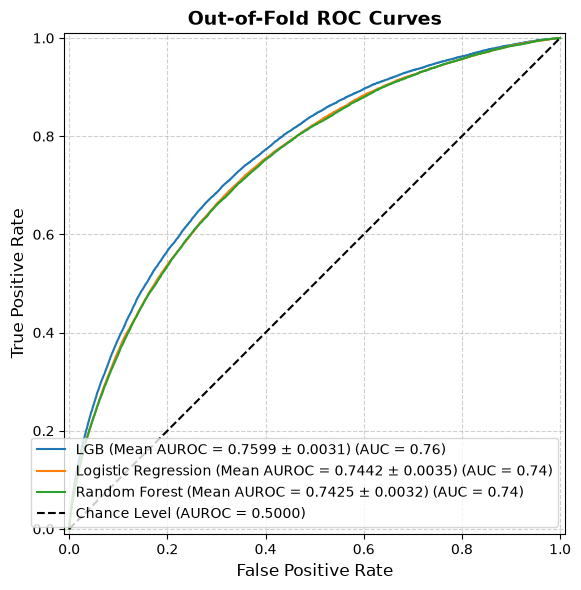

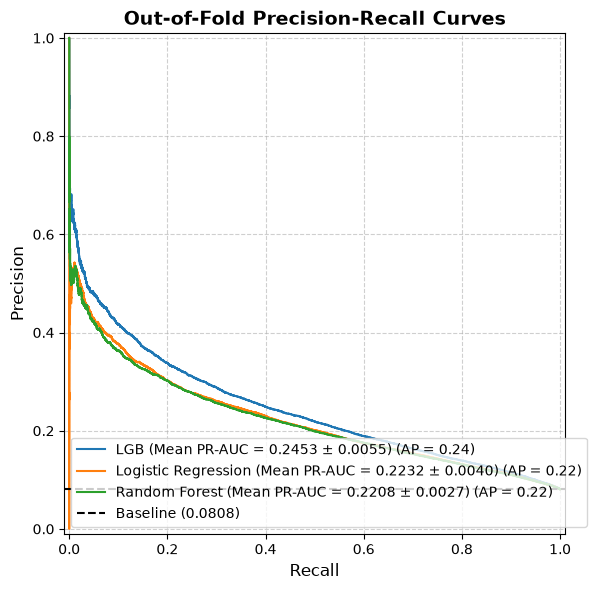

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Dictionary to store out-of-fold predicted probabilities

classifiers = [
    ('LGB', LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=11.5, random_state=42, verbose=-1)),
    ('Logistic Regression', LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced')),
    ('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)),
]

# Run evaluation and generate summary
metrics_df, fig_roc, fig_pr = evaluate_and_plot_models(
    pipeline=pipeline,
    classifiers=classifiers,
    X=X_train_s,
    y=y_train,
    cv=cv
)

# Display tabular evaluation summary
print("\n==========================================")
print("       MODEL EVALUATION SUMMARY TABLE     ")
print("==========================================")
print(metrics_df)

# Show plots
plt.show()

In [9]:
pipeline.set_params(classifier=LGBMClassifier(random_state=42, verbose=-1))

# Note: parameter names use double underscore convention
param_dist = {
    "classifier__n_estimators": [300, 500, 700, 1000],
    "classifier__learning_rate": [0.02, 0.03, 0.05, 0.07, 0.1],
    "classifier__num_leaves": [15, 20, 31, 40, 50, 63],
    "classifier__max_depth": [-1, 5, 7, 10],
    "classifier__min_child_samples": [20, 30, 50, 75, 100],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__reg_alpha": [0, 0.1, 0.5, 1, 2],
    "classifier__reg_lambda": [0, 0.1, 0.5, 1, 2, 5],
    "classifier__scale_pos_weight": [9, 10, 11, 11.5, 12, 13, 15]
}

search = RandomizedSearchCV(pipeline, param_dist, n_iter=50, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1, verbose=0)
search.fit(X_train_s, y_train)

print(f'Best CV AUROC: {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

Best CV AUROC: 0.7617
Best params: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 12, 'classifier__reg_lambda': 1, 'classifier__reg_alpha': 0.1, 'classifier__num_leaves': 40, 'classifier__n_estimators': 500, 'classifier__min_child_samples': 100, 'classifier__max_depth': -1, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.9}


In [10]:
best_pipeline = search.best_estimator_

## Creating an end-to-end pipeline using ColumnTransformers and custom defined functions in the 'src' folder

In [11]:
# Loading the raw application and bureau datasets

df_app = pd.read_csv(data_dir / "application_train.csv")
df_bureau = pd.read_csv(data_dir / "bureau.csv")

X = df_app.drop(columns=["TARGET"])
y = df_app["TARGET"]

# Splitting the raw data into train/ test to prevent data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Saving the train and the test data separately  
X_train_raw['TARGET'] = y_train.values
X_train_raw.to_csv(os.path.join(data_dir, "pipeline_train.csv"), index=False)
X_test_raw['TARGET'] = y_test.values
X_test_raw.to_csv(os.path.join(data_dir, "pipeline_test.csv"), index=False)

# Feature Configuration Parameters

education_categories = [
    "Lower secondary",
    "Secondary / secondary special",
    "Incomplete higher",
    "Higher education",
    "Academic degree",
]
ordinal_cols = ["NAME_EDUCATION_TYPE"]
ohe_cols = [
    "WALLSMATERIAL_MODE",
    "HOUSETYPE_MODE",
    "EMERGENCYSTATE_MODE",
    "NAME_TYPE_SUITE",
]
freq_cols = ["OCCUPATION_TYPE"]

cluster_features = [
    "num__AMT_INCOME_TOTAL",
    "num__AMT_CREDIT",
    "num__CREDIT_INCOME_RATIO",
    "num__AGE",
    "num__EXT_SOURCE_MEAN",
    "num__num_bureau_records",
    "num__DAYS_EMPLOYED",
    "num__AMT_ANNUITY",
]

# Building the Master Pipeline

full_pipeline = Pipeline([
    # Merge Bureau & Impute Missing Flags
    ("bureau_merger", BureauMergerAndImputer(df_bureau=df_bureau)),
    
    # Feature Engineering Steps
    ("drop_high_missing", DropHighMissingColumns(threshold=65.0)),          # dropping columns with more than 65% missing
    ("add_missing_indicators", AddMissingIndicators(threshold=5.0)),        # adding missing indicator columns where missing percentage is > 5%
    ("feature_engineer", ApplicationFeatureEngineer()),                     # feature engineering the merged dataframe
    ("remove_correlated_features", HighCorrelationFilter(threshold=0.95)),  # removing one of the features where correlation score is more than 95%
    ("frequency_encoder", FrequencyEncoder(cols=freq_cols)),                # frequency encoding the 'OCCUPATION_TYPE' column
    
    # Column Transformation & Encoding
    ("preprocessor", DynamicPreprocessingPipeline(                          # preprocessing categorical columns (one-hot encoding, ordinal, frequency encoding)
        education_categories=education_categories,
        ordinal_cols=ordinal_cols,
        ohe_cols=ohe_cols,
        freq_cols=freq_cols
    )),
    
    # Customer Clustering
    ("segmenter", ClusterSegmenterWrapper(cluster_features=cluster_features, n_clusters=2)), # computing & adding cluster number column
    
    # Feature Scaling
    ("scaler", StandardScaler()),
    
    # Final Estimator
    ("classifier", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=40,
        subsample=0.8,
        colsample_bytree=0.9,
        scale_pos_weight=12,
        reg_lambda=1,
        reg_alpha=0.1,
        min_child_samples=100,
        max_depth=-1,
        random_state=42
    ))
])

# fitting the entire raw training data
full_pipeline.fit(X_train_raw, y_train)

# Direct predictions on raw test data
y_pred = full_pipeline.predict(X_test_raw)
y_proba = full_pipeline.predict_proba(X_test_raw)[:, 1]

In [12]:
test_auroc = roc_auc_score(y_test, y_proba)
print(f'Test AUROC: {test_auroc:.4f}')

# saving the model
output_path = Path("../models/best_model.pkl")
joblib.dump(full_pipeline, output_path)
print('Pipeline saved to best_model.pkl')

Test AUROC: 0.7685
Pipeline saved to best_model.pkl
